# [LAB-06] 5. BoxPlot

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
import seaborn as sb

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data("employee_data_40")
origin.head()

📚 어느 기업의 직원 40명을 대상으로 성별과 결혼상태, 나이, 최종학력, 월수입을 조사한 가상의 데이터(인덱스, 메타데이터 없음)


,성별,결혼상태,나이,최종학력,월수입
0,남자,기혼,21,대학교,60
1,남자,기혼,22,대학원,100
2,남자,기혼,33,대학교,200
3,여자,미혼,33,대학교,120
4,남자,미혼,28,대학교,70


## #02. Boxplot 시각화

### 1. 자동 인식 패턴

#### `sb.boxplot()` 함수 사용

- data 파라미터에 `list`, `ndarray`, `Series` 등 모든 연속형 객체를 지정할 수 있다.
- `orient` 파라미터로 방향을 설정한다. (`v` : 세로 (기본값), `h` : 가로)

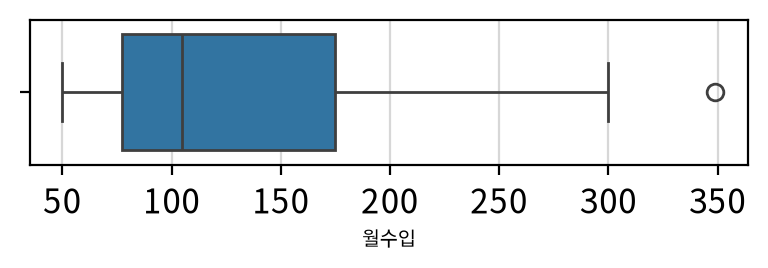

In [3]:
# 그래프 초기화
fig, ax = my_plot.init(width=400, height=150)

# 그래프 그리기
sb.boxplot(data=origin['월수입'], orient="h")
ax.set_xlabel("월수입", fontsize=7)

# 출력
my_plot.show()

#### 💡 인사이트

- 📦 월수입의 중앙값이 약 100~110 수준에 위치함.
- 📏 1사분위수(Q1)는 약 80 전후, 3사분위수(Q3)는 약 170~180 전후로 보여 중간 50% 데이터 범위(IQR)가 비교적 넓음.
- ↗️ 상단 수염(whisker)이 하단보다 훨씬 길어, 분포가 높은 값 방향으로 더 길게 퍼져 있음.
- ⚠️ 약 350 부근에 상단 이상치 1개가 확인됨.

### 2. 자동 인식 패턴에 DataFrame 지정을 위한 데이터 전처리

- 상자그림은 연속형 데이터의 분포를 시각화 하는 그래프이므로, 연속형 데이터만 필터링 한다.

In [4]:
df = origin[['월수입', '나이']]
df.head()

,월수입,나이
0,60,21
1,100,22
2,200,33
3,120,33
4,70,28


### 3. 자동 인식 패턴에 DataFrame을 지정하여 상자그림 시각화

- DataFrame의 모든 컬럼을 한번에 보여 줄 수 있다.

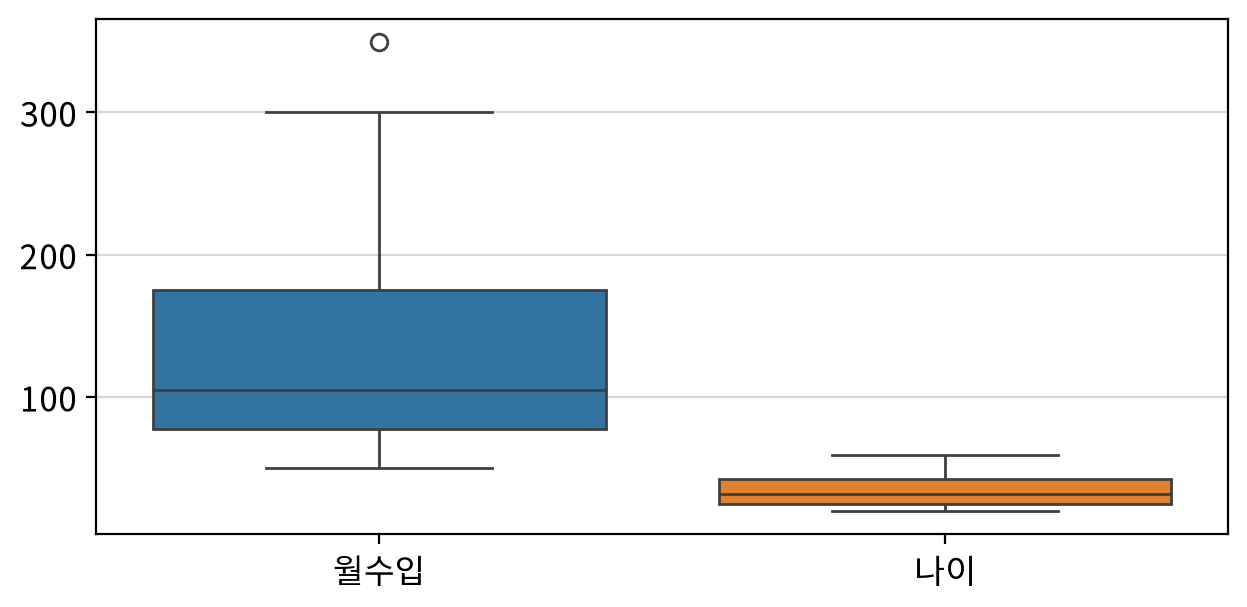

In [5]:
# 그래프 초기화
fig, ax = my_plot.init(width=640, height=320)

# 그래프 그리기
sb.boxplot(data=df, orient="v")

# 출력
my_plot.show()

#### 💡 인사이트

- 📊 월수입의 중앙값은 약 105 수준으로 보임.
- 📦 월수입의 사분위 범위(IQR)는 대략 75~175 구간으로, 분산 폭이 큼.
- 📈 월수입은 상단 수염이 약 300까지 길게 뻗고, 약 350 부근 상단 이상치 1개가 확인됨.
- 👥 나이의 중앙값은 약 32~33 수준으로 보임.
- 📏 나이의 사분위 범위(IQR)는 대략 25~42 구간으로, 월수입 대비 변동 폭이 좁음.
- ✅ 나이에서는 눈에 띄는 이상치가 보이지 않음.
- 🔍 동일 축에서 비교 시, 월수입이 나이보다 분포 퍼짐과 극단값 영향이 훨씬 크게 나타남.

### 4. 개별 데이터 직접 지정 패턴

- **`x` 혹은 `y`중 하나의 파라미터만 지정**
  - `x`에 지정할 경우 가로 그래프가 표시되고, `y`에 지정할 경우 세로 그래프가 표시된다.
  - 가로, 세로 표시 여부에 따라 그래프의 크기를 적절히 설정해야 한다.

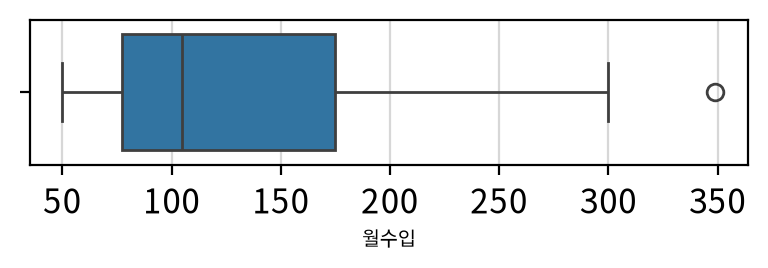

In [6]:
# 그래프 초기화
fig, ax = my_plot.init(width=400, height=150)

# 그래프 그리기
# -> 데이터가 x축으로 전개되므로 가로 방향 그래프가 된다.
sb.boxplot(x=df['월수입'])
ax.set_xlabel("월수입", fontsize=7)

# 출력
my_plot.show()

### 5. 데이터 프레임 + 컬럼명 패턴

- **data 파라미터에 데이터 프레임을 지정**
  - x 혹은 y 파라미터에 표시하고자 하는 컬럼명을 지정한다. (동시 사용 불가)
  - 사용하는 파라미터에 따라 그래프의 방향이 결정된다. (x: 가로 방향, y: 세로 방향)

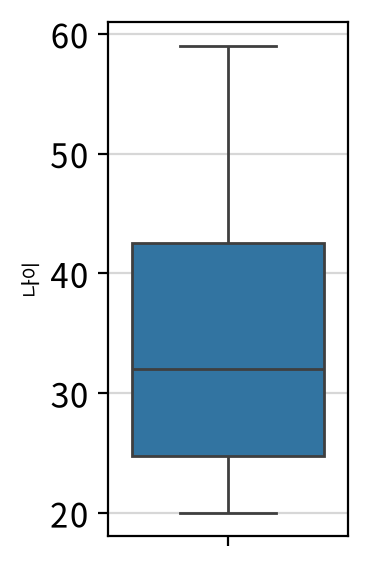

In [7]:
# 그래프 초기화
fig, ax = my_plot.init(width=200, height=300)

# 그래프 그리기
sb.boxplot(data=origin, y='나이')
ax.set_ylabel("나이", fontsize=7)

# 출력
my_plot.show()

#### 💡 인사이트

- 👤 나이의 중앙값이 약 32로 보임.
- 📦 1사분위수(Q1)는 약 25, 3사분위수(Q3)는 약 42로 보여 중간 50%가 이 구간에 분포함.
- 📏 최솟값은 약 20, 최댓값은 약 59로 확인됨.
- ✅ 표시된 이상치는 보이지 않음.
- ↔️ 중앙값이 박스의 중앙보다 약간 아래에 있어, 상위 구간(중앙값~Q3)의 폭이 하위 구간(Q1~중앙값)보다 더 넓게 나타남.

### 6. 범주(hue) 지정

- 하나의 데이터를 범주(명목형 변수)별로 나누어 시각화 한다.

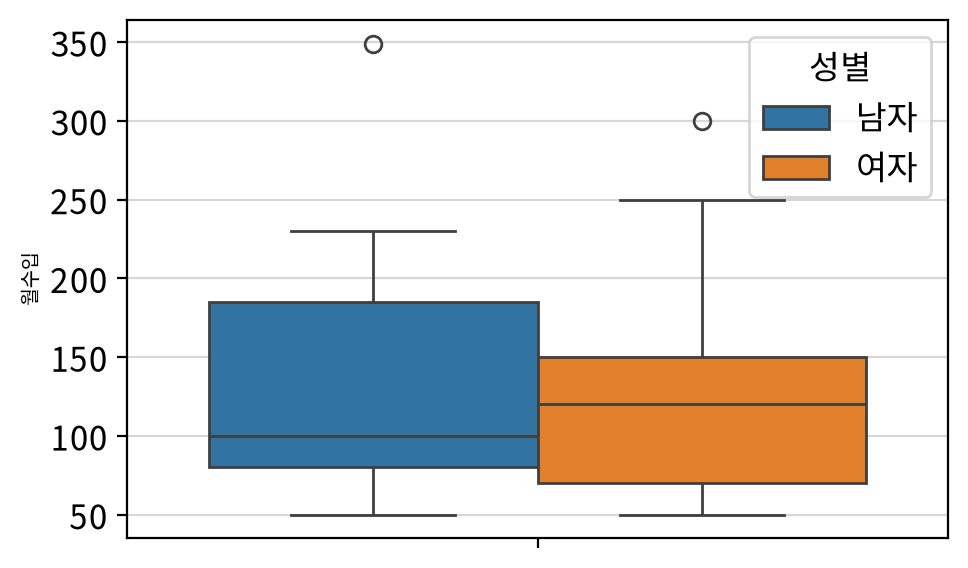

In [8]:
# 그래프 초기화
fig, ax = my_plot.init(width=500, height=300)

# 그래프 그리기
sb.boxplot(data=origin, y='월수입', hue='성별')
ax.set_ylabel("월수입", fontsize=7)

# 출력
my_plot.show()

#### 💡 인사이트

- 👥 성별 비교 시 중앙값은 여자(약 120)가 남자(약 100)보다 높게 나타남.
- 📦 남자의 사분위 범위(IQR)는 대략 80~185, 여자는 대략 70~150으로 보여 남자 분포 폭이 더 넓음.
- 📏 하한 수염은 두 집단 모두 약 50 부근으로 비슷함.
- 📈 상한 수염은 여자(약 250)가 남자(약 230)보다 조금 더 위까지 뻗어 있음.
- ⚠️ 두 집단 모두 상단 이상치가 보이며, 남자는 약 350, 여자는 약 300 부근에서 확인됨.


## #03. 모듈화 기능 확인

### 1. 세로 상자그림

- `y` 파라미터를 설정한다.
- 모듈 코드의 변경사항을 jupyter에 인식시키기 위해 jupyter를 재시작 후 기존 코드를 모두 재실행 해야 한다.

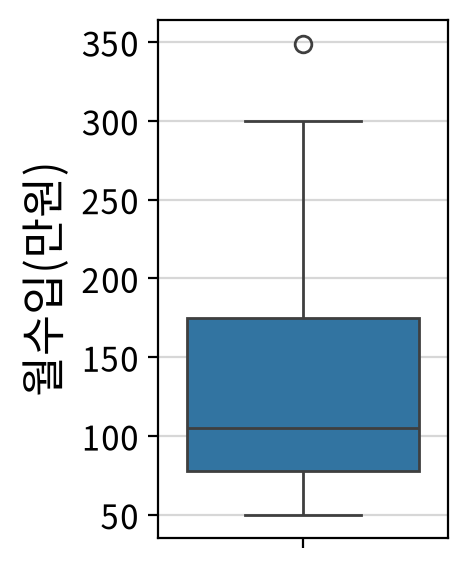

In [9]:
my_plot.boxplot(data=origin, y='월수입', ylabel="월수입(만원)",
                width=250, height=300)

### 2. 가로 상자그림

- `x` 파라미터를 설정한다.

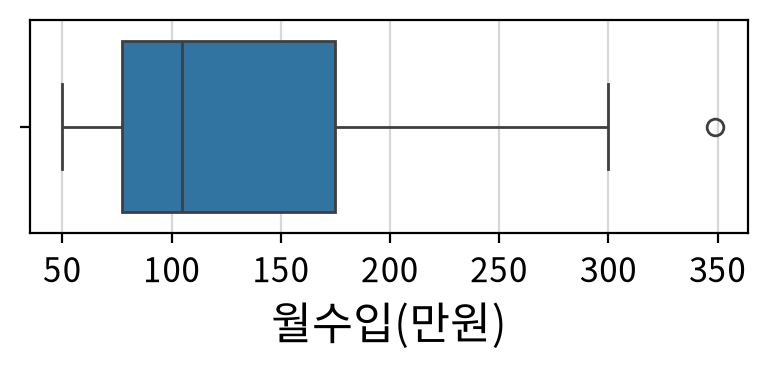

In [10]:
my_plot.boxplot(data=origin, x='월수입', xlabel="월수입(만원)",
                width=400, height=200)

### 3. 자동 설정 (세로 상자그림)

- 데이터 프레임만 지정한다. 기본값은 세로 상자 그림이다.

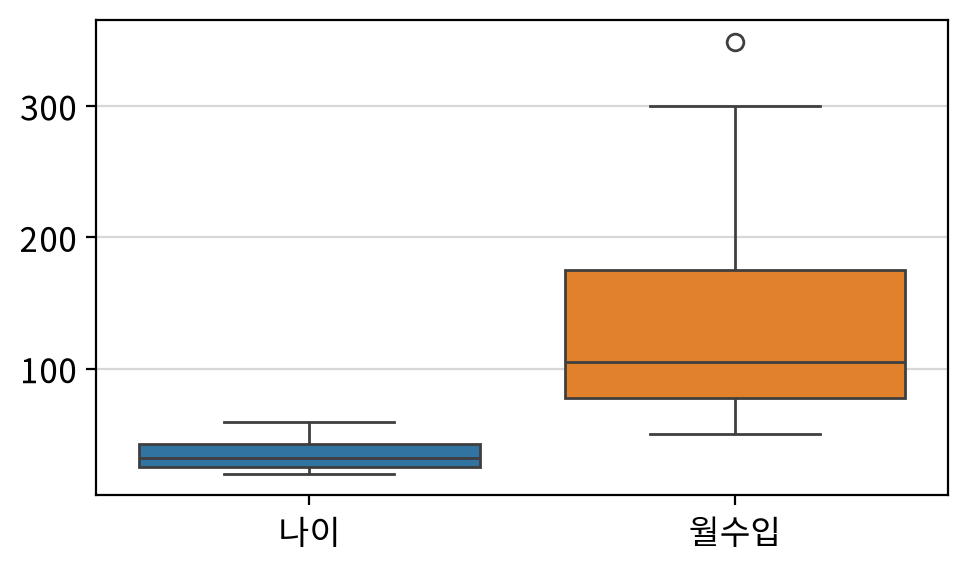

In [11]:
my_plot.boxplot(data=origin, width=500, height=300)

### 4. 자동 설정 (가로 상자그림)

- 데이터 프레임을 지정하면서 `orient`를 `h`로 설정한다.

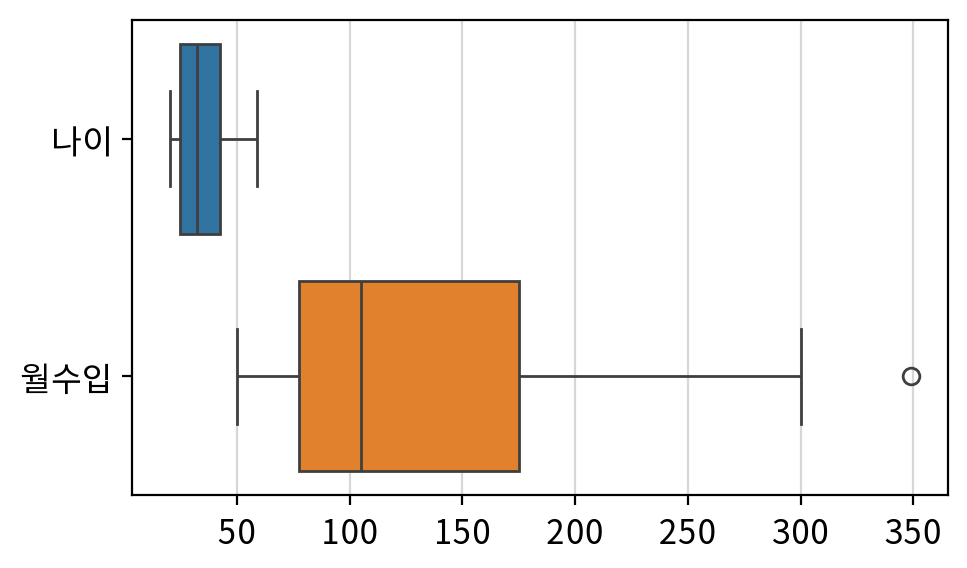

In [12]:
my_plot.boxplot(data=origin, orient="h", 
                width=500, height=300)

### 5. 범주에 따른 구분

- `x`혹은 `y` 파라미터를 설정하고, `hue` 파라미터를 지정한다.
- 여기서는 색상 팔레트를 `GnBu`로 설정함

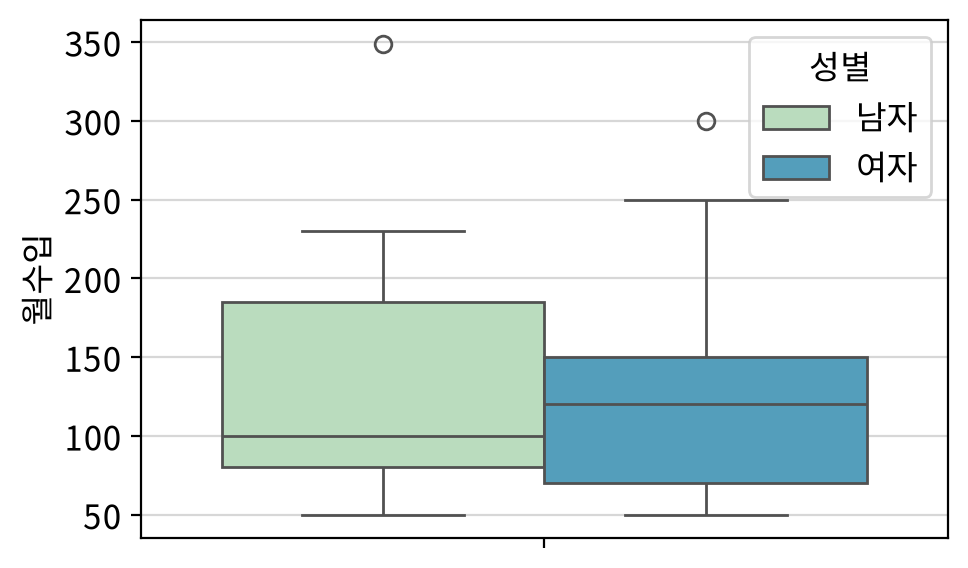

In [13]:
my_plot.boxplot(data=origin, y='월수입', hue='성별', 
                width=500, height=300, palette="GnBu")